# **09 - Model comparison, selection and 2026-2028 projection**

**Question.** Which model is best to estimate what a tenant will pay in future years?

All models were trained on 2022-2024 and evaluated on 2025 (TEST). This notebook only reads the runs saved under `reports/` (`reports/metrics/*.json` and `reports/predictions/*.parquet`) and does not retrain any model, except the chosen one in Step 4.

**Steps.** (1) leaderboard of the valid runs per track, with the oracle diagnostics (`valid=False`) shown separately and a comparison by model family; (2) selection with the rule of `CLAUDE.md`: lowest WAPE, one-standard-error rule with `paired_bootstrap_wape_diff` against the leader, ties to the simplest and least biased model, and then the requirement that the winner can extrapolate a trend; (3) robustness of the winner and of the runner-up; (4) refit of the chosen model on 2022-2025 and extrapolation scenarios for 2026-2028.

**Tie-break definitions.** *One standard error*: a model ties with the leader when its WAPE difference to the leader is at most one bootstrap standard error of that difference (1,000 resamples). *Simplest*: lowest value of an ordinal complexity level defined in `rent_model/compare.py` (group medians < unsupervised medians < linear < trees < boosting < pipelines that combine several fitted components). *Least biased*: smallest absolute aggregate bias. **Extrapolation** is classified by how the model handles time: a forecasted index (hybrid), a log-linear trend added back (detrended models) or a linear time feature can extrapolate; trees with a time feature are flat beyond the last TRAIN month and static models have no time information, so they cannot.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'rent_model').exists())
sys.path.insert(0, str(ROOT / 'src'))

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rent_model import config
from rent_model.boosting import BoostedModel, required_columns
from rent_model.compare import (FAMILIES, annual_cash_cost, area_buckets, bootstrap_best_share, error_by_group,
                                family_table, interval_multipliers, load_predictions, load_runs, one_se_selection,
                                profile_frame, ranking, representative_profile)
from rent_model.data import load_clean
from rent_model.features import build_features, build_target, select_track
from rent_model.hybrid import StructureModel, adjust_target, oracle_index
from rent_model.metrics import paired_bootstrap_wape_diff, wape
from rent_model.splits import temporal_split
from rent_model.ts_index import ALPHAS, forecast, log_index

pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.dpi'] = 100
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
FAMILY_COLORS = dict(zip(FAMILIES, ['#9e9e9e', '#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#ff7f0e', '#17becf']))
print('Random seed:', config.RANDOM_SEED)

Random seed: 42


## Step 1 - Leaderboard

In [2]:
runs = load_runs()
valid, invalid = ranking(runs)
print(f"{len(runs)} runs loaded ({runs['model_id'].nunique()} models x {runs['track'].nunique()} tracks); "
      f"valid {len(valid)}, excluded from the ranking (valid=False): {len(invalid)}")
show = ['rank', 'model_id', 'family', 'wape_pct', 'mae', 'mdape_pct', 'median_bias_pct', 'aggregate_bias_pct',
        'mape_dq_median_pct', 'rmse_log', 'r2_log', 'extrapolation']
for track in config.TRACKS:
    print(f'{track}: leaderboard of the valid runs (top 15 of {int((valid.track == track).sum())}; the full table is saved to reports/metrics/leaderboard.csv)')
    display(valid[valid['track'] == track][show].head(15).set_index('rank'))

66 runs loaded (33 models x 2 tracks); valid 62, excluded from the ranking (valid=False): 4
jeonse: leaderboard of the valid runs (top 15 of 31; the full table is saved to reports/metrics/leaderboard.csv)


,model_id,family,wape_pct,mae,mdape_pct,median_bias_pct,aggregate_bias_pct,mape_dq_median_pct,rmse_log,r2_log,extrapolation
rank,,,,,,,,,,,
1,hgb_legal_dong,boosting,15.8354,"7,137.1232",12.6760,-7.3684,-8.5658,18.7190,0.2556,0.8855,none
2,hgb_time,boosting,17.3111,"7,802.2305",13.0657,-3.9480,-4.0113,19.9779,0.2817,0.8609,tree time feature (cannot extrapolate)
3,hgb_time_kmeans,unsupervised-assisted,17.3424,"7,816.3551",12.9657,-3.8072,-4.0169,19.9833,0.2822,0.8604,tree time feature (cannot extrapolate)
4,hgb_time_tier,unsupervised-assisted,17.3508,"7,820.1270",13.0637,-3.9028,-3.9739,19.9843,0.2820,0.8607,tree time feature (cannot extrapolate)
5,hgb_time_gmm,unsupervised-assisted,17.3771,"7,832.0040",13.0598,-3.9049,-4.0547,19.9316,0.2827,0.8600,tree time feature (cannot extrapolate)
6,hybrid_hgb,time-series/hybrid,17.4448,"7,862.4920",12.9598,-3.3505,-5.0263,20.4127,0.2806,0.8620,forecasted index
7,hgb_detrended,boosting,17.6481,"7,954.1463",13.3657,5.2326,3.3864,22.6308,0.2925,0.8501,log-linear trend (detrended)
8,rf_time,forest,17.9051,"8,069.9658",13.6291,-5.1635,-6.4563,20.4509,0.2912,0.8514,tree time feature (cannot extrapolate)
9,rf_detrended,forest,17.9091,"8,071.7713",13.5941,5.2498,2.7507,22.7957,0.3003,0.8419,log-linear trend (detrended)


wolse: leaderboard of the valid runs (top 15 of 31; the full table is saved to reports/metrics/leaderboard.csv)


,model_id,family,wape_pct,mae,mdape_pct,median_bias_pct,aggregate_bias_pct,mape_dq_median_pct,rmse_log,r2_log,extrapolation
rank,,,,,,,,,,,
1,hgb_legal_dong,boosting,44.3335,33.2343,35.3340,-16.9086,-21.6673,75.0369,0.6837,0.3655,none
2,hgb_detrended,boosting,45.3293,33.9808,35.7666,-16.9244,-22.4758,77.0722,0.6942,0.3459,log-linear trend (detrended)
3,hgb_static,boosting,45.5432,34.1412,36.0367,-17.6542,-23.2012,76.9509,0.6944,0.3454,none
4,hgb_time_gmm,unsupervised-assisted,45.5640,34.1567,37.2668,-18.1697,-22.3026,76.3577,0.6959,0.3426,tree time feature (cannot extrapolate)
5,hgb_time,boosting,45.7417,34.2900,37.3742,-18.2042,-22.4644,76.0627,0.6973,0.3400,tree time feature (cannot extrapolate)
6,hgb_time_tier,unsupervised-assisted,45.7446,34.2921,37.3482,-18.4341,-22.5572,76.0368,0.6970,0.3405,tree time feature (cannot extrapolate)
7,rf_detrended,forest,45.7560,34.3007,35.7110,-16.1919,-23.1224,77.3695,0.6997,0.3355,log-linear trend (detrended)
8,hgb_time_kmeans,unsupervised-assisted,45.7855,34.3228,37.4642,-18.3461,-22.5682,76.1375,0.6973,0.3400,tree time feature (cannot extrapolate)
9,rf_static,forest,45.9594,34.4532,35.9485,-16.8654,-23.7873,76.7172,0.7004,0.3342,none


**Interpretation.** The 66 saved runs (33 models in two tracks) include 62 valid ones. In Jeonse the first eleven places are tree-based models (boosting, forest and the HGB hybrid): `hgb_legal_dong` leads with a WAPE of 15.8354%, followed by `hgb_time` (17.3111%) and the HGB models with unsupervised features (17.3424% to 17.3771%); the best linear model, `ridge_time_rich`, is 12th (23.0944%). In Wolse `hgb_legal_dong` also leads (44.3335%), `hgb_detrended` is second (45.3293%), and the naive `baseline_district_type_area` (46.9591%) is 12th, ahead of every linear model (the best, `ridge_time_rich`, has 49.0983%). The ranking by WAPE hides differences in bias: in Jeonse the leader has a median bias of -7.3684% while `hgb_time` has -3.9480%, and among the 15 models shown only the two detrended tree models have a positive median bias (+5.2326% and +5.2498%). In Wolse the baseline has the smallest bias of the models shown (median -7.4074%, aggregate -14.5804%) against -16.9086% and -21.6673% for the leader, but a larger error. The median MAPE by district x quarter is much higher in Wolse (75.0369% for the leader) than in Jeonse (18.7190%) because many Wolse rents are small.

In [3]:
print('Excluded from the ranking: oracle diagnostics (use TEST information, not valid models)')
display(invalid[['track', 'model_id', 'family', 'wape_pct', 'median_bias_pct', 'aggregate_bias_pct', 'rmse_log', 'r2_log']].set_index(['track', 'model_id']))

Excluded from the ranking: oracle diagnostics (use TEST information, not valid models)


family  wape_pct  median_bias_pct  aggregate_bias_pct  rmse_log  r2_log
track  model_id                                                                                                
jeonse hybrid_hgb_oracle    time-series/hybrid   17.2465          -2.8474             -4.4224    0.2799  0.8627
       hybrid_ridge_oracle  time-series/hybrid   22.8945          -4.2523             -7.9031    0.3482  0.7875
wolse  hybrid_hgb_oracle    time-series/hybrid   44.8760         -15.0720            -20.9506    0.6936  0.3470
       hybrid_ridge_oracle  time-series/hybrid   49.3913         -15.3338            -24.2409    0.7435  0.2497

**Interpretation.** The four oracle runs use the index fitted with 2025 data and are excluded from the ranking. They are shown only as an upper bound: the HGB oracle would have a WAPE of 17.2465% in Jeonse and 44.8760% in Wolse, and the ridge oracle 22.8945% and 49.3913%. They are not achievable performance.

### Family comparison

jeonse: WAPE by model family (valid runs)


,n_models,best_wape,median_wape,worst_wape,best_model
family,,,,,
baseline,6,27.2510,43.0806,55.5593,baseline_district_type_area
linear,8,23.0944,24.2070,24.3701,ridge_time_rich
forest,3,17.9051,17.9091,18.9266,rf_time
boosting,4,15.8354,17.4796,18.5858,hgb_legal_dong
unsupervised-assisted,6,17.3424,20.3839,24.0436,hgb_time_kmeans
pure unsupervised,2,37.0993,39.4306,41.7619,gmm_median
time-series/hybrid,2,17.4448,20.2902,23.1356,hybrid_hgb


wolse: WAPE by model family (valid runs)


,n_models,best_wape,median_wape,worst_wape,best_model
family,,,,,
baseline,6,46.9591,53.3475,56.5529,baseline_district_type_area
linear,8,49.0983,49.9677,51.3992,ridge_time_rich
forest,3,45.7560,45.9594,46.3507,rf_detrended
boosting,4,44.3335,45.4363,45.7417,hgb_legal_dong
unsupervised-assisted,6,45.5640,48.1180,51.3471,hgb_time_gmm
pure unsupervised,2,51.8733,53.1657,54.4581,gmm_median
time-series/hybrid,2,46.1356,48.3143,50.4930,hybrid_hgb


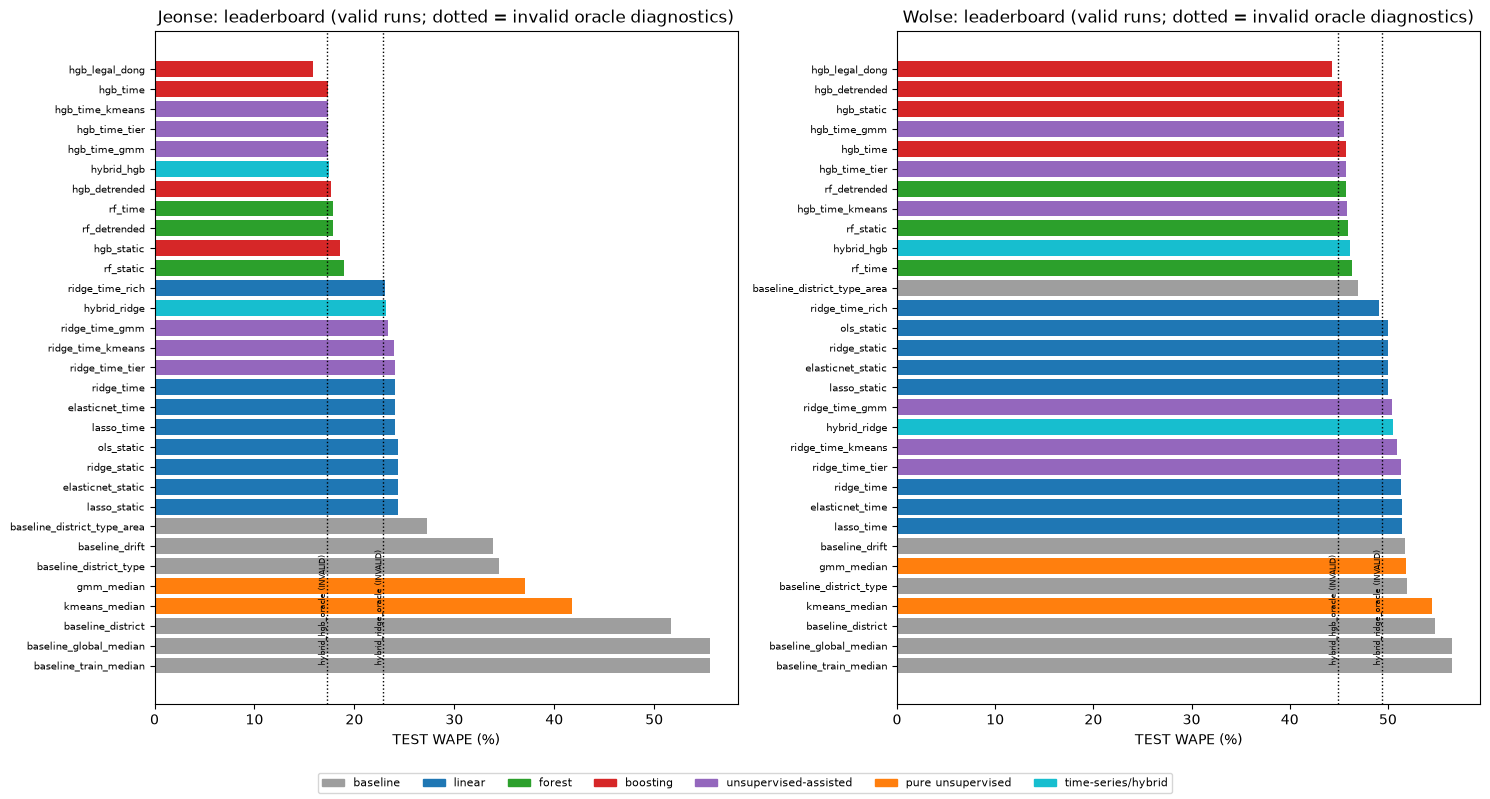

In [4]:
fam = family_table(valid)
for track in config.TRACKS:
    print(f'{track}: WAPE by model family (valid runs)')
    display(fam[fam['track'] == track].set_index('family').drop(columns='track').loc[[f for f in FAMILIES if f in set(fam[fam['track'] == track]['family'])]])

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
for ax, track in zip(axes, config.TRACKS):
    v = valid[valid['track'] == track].sort_values('wape_pct', ascending=False)
    ax.barh(v['model_id'], v['wape_pct'], color=[FAMILY_COLORS[f] for f in v['family']])
    for _, r in invalid[invalid['track'] == track].iterrows():
        ax.axvline(r['wape_pct'], color='black', ls=':', lw=1)
        ax.text(r['wape_pct'], 0, r['model_id'] + ' (INVALID)', rotation=90, fontsize=6, va='bottom', ha='right')
    ax.set_xlabel('TEST WAPE (%)'); ax.set_title(f'{track.capitalize()}: leaderboard (valid runs; dotted = invalid oracle diagnostics)')
    ax.tick_params(axis='y', labelsize=7)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in FAMILY_COLORS.values()]
fig.legend(handles, FAMILY_COLORS.keys(), loc='lower center', ncol=7, fontsize=8)
plt.tight_layout(rect=(0, 0.04, 1, 1)); plt.savefig(config.FIGURES_DIR / '09_leaderboard.png', dpi=130); plt.show()

**Interpretation.** Boosting is the best family in both tracks (best WAPE 15.8354% in Jeonse, 44.3335% in Wolse), followed in Jeonse by the HGB models with unsupervised features (17.3424%), the hybrid (17.4448%) and the forest (17.9051%), and in Wolse by the HGB models with unsupervised features (45.5640%), the forest (45.7560%), the hybrid (46.1356%) and the baselines (46.9591%). Linear models are behind the trees (23.0944% in Jeonse, 49.0983% in Wolse; in Wolse they are worse than the best baseline). Pure unsupervised predictors have the worst best-model WAPE of all families (37.0993% in Jeonse and 51.8733% in Wolse, both from `gmm_median`). The gap between the best and the median model of a family is small for forest (17.9051% and 17.9091% in Jeonse) and large for baselines (27.2510% and 43.0806%).

### Supervised vs unsupervised

In [5]:
wape_of = lambda track, model_id: float(runs[(runs['track'] == track) & (runs['model_id'] == model_id)]['wape_pct'].iloc[0])
pairs = [(f'{base}_{suffix}', base) for base in ['ridge_time', 'hgb_time'] for suffix in ['kmeans', 'tier', 'gmm']]
rows = []
for track in config.TRACKS:
    for assisted, plain in pairs:
        rows.append({'track': track, 'comparison': f'{assisted} vs {plain}', 'wape_assisted': wape_of(track, assisted),
                     'wape_plain': wape_of(track, plain), 'delta_pts': wape_of(track, assisted) - wape_of(track, plain)})
    for pure, ref in [('kmeans_median', 'baseline_district_type'), ('gmm_median', 'baseline_district_type')]:
        rows.append({'track': track, 'comparison': f'{pure} vs {ref}', 'wape_assisted': wape_of(track, pure),
                     'wape_plain': wape_of(track, ref), 'delta_pts': wape_of(track, pure) - wape_of(track, ref)})
unsup = pd.DataFrame(rows).set_index(['track', 'comparison'])
display(unsup)
sup = valid[valid['family'].isin(['linear', 'forest', 'boosting'])]
for track in config.TRACKS:
    best = lambda frame: frame.loc[frame['wape_pct'].idxmin()]
    t = lambda family: valid[(valid['track'] == track) & (valid['family'] == family)]
    print(track, '| best supervised:', best(sup[sup['track'] == track])[['model_id', 'wape_pct']].tolist(),
          '| best unsupervised-assisted:', best(t('unsupervised-assisted'))[['model_id', 'wape_pct']].tolist(),
          '| best pure unsupervised:', best(t('pure unsupervised'))[['model_id', 'wape_pct']].tolist(),
          '| best time-series/hybrid:', best(t('time-series/hybrid'))[['model_id', 'wape_pct']].tolist())

wape_assisted  wape_plain  delta_pts
track  comparison                                                                   
jeonse ridge_time_kmeans vs ridge_time                23.9687     24.0436    -0.0749
       ridge_time_tier vs ridge_time                  24.0436     24.0436    -0.0000
       ridge_time_gmm vs ridge_time                   23.3908     24.0436    -0.6528
       hgb_time_kmeans vs hgb_time                    17.3424     17.3111     0.0313
       hgb_time_tier vs hgb_time                      17.3508     17.3111     0.0397
       hgb_time_gmm vs hgb_time                       17.3771     17.3111     0.0661
       kmeans_median vs baseline_district_type        41.7619     34.4687     7.2933
       gmm_median vs baseline_district_type           37.0993     34.4687     2.6306
wolse  ridge_time_kmeans vs ridge_time                50.9666     51.3471    -0.3804
       ridge_time_tier vs ridge_time                  51.3471     51.3471    -0.0000
       ridge_time_gmm vs ridge_time                   50.4504     51.3471    -0.8967
       hgb_time_kmeans vs hgb_time                    45.7855     45.7417     0.0438
       hgb_time_tier vs hgb_time                      45.7446     45.7417     0.0029
       hgb_time_gmm vs hgb_time                       45.5640     45.7417    -0.1777
       kmeans_median vs baseline_district_type        54.4581     51.9313     2.5268
       gmm_median vs baseline_district_type           51.8733     51.9313    -0.0580

jeonse | best supervised: ['hgb_legal_dong', np.float64(15.835359981110352)] | best unsupervised-assisted: ['hgb_time_kmeans', np.float64(17.342393282758977)] | best pure unsupervised: ['gmm_median', np.float64(37.09926365808138)] | best time-series/hybrid: ['hybrid_hgb', np.float64(17.444758713756546)]
wolse | best supervised: ['hgb_legal_dong', np.float64(44.33351248863339)] | best unsupervised-assisted: ['hgb_time_gmm', np.float64(45.56395144002207)] | best pure unsupervised: ['gmm_median', np.float64(51.87327210466158)] | best time-series/hybrid: ['hybrid_hgb', np.float64(46.135626084605086)]


**Interpretation.** Supervised models win over unsupervised ones. The best supervised model is `hgb_legal_dong` (15.8354% and 44.3335%), the best unsupervised-assisted model has 17.3424% (`hgb_time_kmeans`) in Jeonse and 45.5640% (`hgb_time_gmm`) in Wolse, and the best pure unsupervised model 37.0993% and 51.8733% (`gmm_median`). Adding unsupervised features to boosting does not help: the differences with `hgb_time` are between +0.0029 and +0.0661 points, except `hgb_time_gmm` in Wolse (-0.1777). For ridge the gains are larger but limited: `ridge_time_gmm` improves by 0.6528 (Jeonse) and 0.8967 (Wolse) points and `ridge_time_kmeans` by 0.0749 and 0.3804, and `ridge_time_tier` does not change (-0.0000). Pure unsupervised medians are worse than `baseline_district_type` except `gmm_median` in Wolse (-0.0580), where it is equivalent. Note that `hgb_legal_dong` is a supervised model that uses a neighbourhood categorical, not an unsupervised feature.

## Step 2 - Selection

In [6]:
y_test, preds = {}, {}
df = load_clean()
data = {}
for track, spec in config.TRACKS.items():
    train, test = temporal_split(select_track(df, track))
    data[track] = dict(train=train, test=test, target=spec['target'])
    ids = list(valid[valid['track'] == track]['model_id'])
    loaded = {m: load_predictions(track, m) for m in ids}
    y_test[track] = loaded[ids[0]]['y_true'].to_numpy()
    assert all(np.allclose(p['y_true'].to_numpy(), y_test[track]) for p in loaded.values()), 'predictions are not on the same TEST rows'
    assert np.allclose(test[spec['target']].to_numpy(), y_test[track]) and (loaded[ids[0]]['district_name'].to_numpy() == test['district_name'].to_numpy()).all()
    preds[track] = {m: p['y_pred'].to_numpy() for m, p in loaded.items()}
    print(f"{track}: {len(ids)} valid models, {len(y_test[track]):,} TEST rows, predictions aligned with the TEST rows")

jeonse: 31 valid models, 37,935 TEST rows, predictions aligned with the TEST rows
wolse: 31 valid models, 57,829 TEST rows, predictions aligned with the TEST rows


**Interpretation.** All 31 valid models of each track have predictions on the same TEST rows (37,935 in Jeonse and 57,829 in Wolse), so the paired bootstrap comparisons below are valid.

In [7]:
selection, tables = {}, {}
for track in config.TRACKS:
    v = valid[valid['track'] == track]
    table, leader, stat_winner = one_se_selection(y_test[track], preds[track], v, n_boot=1000)
    tables[track] = table.merge(v[['model_id', 'family', 'extrapolation', 'can_extrapolate']], on='model_id')
    selection[track] = {'leader': leader, 'stat_winner': stat_winner}
    print(f"{track}: leader = {leader} (WAPE {wape(y_test[track], preds[track][leader]):.4f}%); one-SE tie set = "
          f"{list(table[table['tie_with_leader']]['model_id'])}; simplest and least biased among ties = {stat_winner}")
    display(tables[track][['model_id', 'family', 'wape_pct', 'diff_vs_leader', 'se_diff', 'ci_low', 'ci_high', 'tie_with_leader',
                           'complexity', 'aggregate_bias_pct', 'extrapolation']].head(10))

jeonse: leader = hgb_legal_dong (WAPE 15.8354%); one-SE tie set = ['hgb_legal_dong']; simplest and least biased among ties = hgb_legal_dong


,model_id,family,wape_pct,diff_vs_leader,se_diff,ci_low,ci_high,tie_with_leader,complexity,aggregate_bias_pct,extrapolation
0,hgb_legal_dong,boosting,15.8354,0.0000,0.0000,0.0000,0.0000,True,13,-8.5658,none
1,hgb_time,boosting,17.3111,1.4757,0.0813,1.3132,1.6333,False,12,-4.0113,tree time feature (cannot extrapolate)
2,hgb_time_kmeans,unsupervised-assisted,17.3424,1.5070,0.0807,1.3465,1.6666,False,15,-4.0169,tree time feature (cannot extrapolate)
3,hgb_time_tier,unsupervised-assisted,17.3508,1.5154,0.0811,1.3535,1.6758,False,15,-3.9739,tree time feature (cannot extrapolate)
4,hgb_time_gmm,unsupervised-assisted,17.3771,1.5418,0.0839,1.3676,1.7004,False,15,-4.0547,tree time feature (cannot extrapolate)
5,hybrid_hgb,time-series/hybrid,17.4448,1.6094,0.0778,1.4563,1.7576,False,14,-5.0263,forecasted index
6,hgb_detrended,boosting,17.6481,1.8128,0.0938,1.6273,1.9933,False,13,3.3864,log-linear trend (detrended)
7,rf_time,forest,17.9051,2.0697,0.0843,1.9031,2.2374,False,10,-6.4563,tree time feature (cannot extrapolate)
8,rf_detrended,forest,17.9091,2.0737,0.0984,1.8811,2.2546,False,11,2.7507,log-linear trend (detrended)
9,hgb_static,boosting,18.5858,2.7504,0.0752,2.6023,2.8971,False,12,-9.3616,none


wolse: leader = hgb_legal_dong (WAPE 44.3335%); one-SE tie set = ['hgb_legal_dong']; simplest and least biased among ties = hgb_legal_dong


,model_id,family,wape_pct,diff_vs_leader,se_diff,ci_low,ci_high,tie_with_leader,complexity,aggregate_bias_pct,extrapolation
0,hgb_legal_dong,boosting,44.3335,0.0000,0.0000,0.0000,0.0000,True,13,-21.6673,none
1,hgb_detrended,boosting,45.3293,0.9958,0.0889,0.8129,1.1657,False,13,-22.4758,log-linear trend (detrended)
2,hgb_static,boosting,45.5432,1.2097,0.0887,1.0295,1.3803,False,12,-23.2012,none
3,hgb_time_gmm,unsupervised-assisted,45.5640,1.2304,0.0935,1.0462,1.4212,False,15,-22.3026,tree time feature (cannot extrapolate)
4,hgb_time,boosting,45.7417,1.4082,0.0976,1.2090,1.6059,False,12,-22.4644,tree time feature (cannot extrapolate)
5,hgb_time_tier,unsupervised-assisted,45.7446,1.4111,0.0963,1.2160,1.6060,False,15,-22.5572,tree time feature (cannot extrapolate)
6,rf_detrended,forest,45.7560,1.4225,0.1032,1.2257,1.6308,False,11,-23.1224,log-linear trend (detrended)
7,hgb_time_kmeans,unsupervised-assisted,45.7855,1.4520,0.0951,1.2609,1.6456,False,15,-22.5682,tree time feature (cannot extrapolate)
8,rf_static,forest,45.9594,1.6259,0.1032,1.4334,1.8350,False,10,-23.7873,none
9,hybrid_hgb,time-series/hybrid,46.1356,1.8021,0.0887,1.6284,1.9689,False,14,-25.0701,forecasted index


**Interpretation.** Applying the rule of `CLAUDE.md` without further requirements, `hgb_legal_dong` wins in both tracks and the one-standard-error tie set contains only the leader: the closest model in Jeonse is `hgb_time`, 1.4757 points behind (bootstrap standard error 0.0813, interval 1.3132 to 1.6333), and in Wolse it is `hgb_detrended`, 0.9958 points behind (standard error 0.0889, interval 0.8129 to 1.1657). The leader is clear in statistical terms.

### Extrapolation check

In [8]:
for track in config.TRACKS:
    v = valid[valid['track'] == track].set_index('model_id')
    leader = selection[track]['stat_winner']
    kind, can = v.loc[leader, ['extrapolation', 'can_extrapolate']]
    print(f"{track}: statistical winner {leader}: time handling = '{kind}', can extrapolate a trend = {bool(can)}")
    ex = valid[(valid['track'] == track) & valid['can_extrapolate']]
    t_ex, leader_ex, winner_ex = one_se_selection(y_test[track], {m: preds[track][m] for m in ex['model_id']}, ex, n_boot=1000)
    selection[track].update(ex_leader=leader_ex, winner=winner_ex if not can else leader, can_stat=bool(can))
    if can:
        print('   -> the statistical winner can extrapolate; it is the chosen model')
    else:
        print(f"   -> best model that can extrapolate: leader {leader_ex}; one-SE tie set {list(t_ex[t_ex['tie_with_leader']]['model_id'])}; chosen = {winner_ex}")
    display(t_ex.merge(ex[['model_id', 'extrapolation']], on='model_id')[['model_id', 'extrapolation', 'wape_pct', 'diff_vs_leader', 'se_diff', 'ci_low', 'ci_high',
                                                                          'tie_with_leader', 'complexity', 'aggregate_bias_pct']].head(8))
    w = selection[track]['winner']
    boot = paired_bootstrap_wape_diff(y_test[track], preds[track][w], preds[track][selection[track]['stat_winner']], seed=config.RANDOM_SEED)
    selection[track]['cost'] = boot
    print(f"   cost of requiring extrapolation: WAPE {wape(y_test[track], preds[track][w]):.4f}% for {w} against "
          f"{wape(y_test[track], preds[track][selection[track]['stat_winner']]):.4f}% for {selection[track]['stat_winner']} "
          f"(difference {boot['diff']:.4f} points, 95% interval {boot['ci_low']:.4f} to {boot['ci_high']:.4f})")

jeonse: statistical winner hgb_legal_dong: time handling = 'none', can extrapolate a trend = False


   -> best model that can extrapolate: leader hybrid_hgb; one-SE tie set ['hybrid_hgb']; chosen = hybrid_hgb


,model_id,extrapolation,wape_pct,diff_vs_leader,se_diff,ci_low,ci_high,tie_with_leader,complexity,aggregate_bias_pct
0,hybrid_hgb,forecasted index,17.4448,0.0000,0.0000,0.0000,0.0000,True,14,-5.0263
1,hgb_detrended,log-linear trend (detrended),17.6481,0.2034,0.0590,0.0835,0.3205,False,13,3.3864
2,rf_detrended,log-linear trend (detrended),17.9091,0.4643,0.0704,0.3285,0.5948,False,11,2.7507
3,ridge_time_rich,linear time feature,23.0944,5.6497,0.0958,5.4575,5.8307,False,8,-10.6128
4,hybrid_ridge,forecasted index,23.1356,5.6908,0.1007,5.4957,5.8836,False,10,-8.4734
5,ridge_time_gmm,linear time feature,23.3908,5.9460,0.1033,5.7447,6.1427,False,9,-11.3437
6,ridge_time_kmeans,linear time feature,23.9687,6.5240,0.1031,6.3187,6.7195,False,9,-11.7438
7,ridge_time_tier,linear time feature,24.0436,6.5988,0.1036,6.4030,6.8003,False,9,-11.9167


   cost of requiring extrapolation: WAPE 17.4448% for hybrid_hgb against 15.8354% for hgb_legal_dong (difference 1.6094 points, 95% interval 1.4563 to 1.7576)
wolse: statistical winner hgb_legal_dong: time handling = 'none', can extrapolate a trend = False


   -> best model that can extrapolate: leader hgb_detrended; one-SE tie set ['hgb_detrended']; chosen = hgb_detrended


,model_id,extrapolation,wape_pct,diff_vs_leader,se_diff,ci_low,ci_high,tie_with_leader,complexity,aggregate_bias_pct
0,hgb_detrended,log-linear trend (detrended),45.3293,0.0000,0.0000,0.0000,0.0000,True,13,-22.4758
1,rf_detrended,log-linear trend (detrended),45.7560,0.4267,0.0642,0.3054,0.5514,False,11,-23.1224
2,hybrid_hgb,forecasted index,46.1356,0.8063,0.0199,0.7657,0.8436,False,14,-25.0701
3,ridge_time_rich,linear time feature,49.0983,3.7689,0.0930,3.5878,3.9522,False,8,-28.9682
4,ridge_time_gmm,linear time feature,50.4504,5.1211,0.1065,4.9101,5.3363,False,9,-29.9126
5,hybrid_ridge,forecasted index,50.4930,5.1637,0.1150,4.9394,5.3911,False,10,-28.1816
6,ridge_time_kmeans,linear time feature,50.9666,5.6373,0.1143,5.4144,5.8617,False,9,-30.7961
7,ridge_time_tier,linear time feature,51.3471,6.0177,0.1148,5.7969,6.2405,False,9,-30.8606


   cost of requiring extrapolation: WAPE 45.3293% for hgb_detrended against 44.3335% for hgb_legal_dong (difference 0.9958 points, 95% interval 0.8129 to 1.1657)


**Interpretation.** `hgb_legal_dong` uses no time information (`none`), so it cannot extrapolate a trend beyond 2025 and is not chosen. Among the models that can extrapolate (forecasted index, log-linear trend or linear time feature), `hybrid_hgb` is the best in Jeonse (17.4448%): the next one, `hgb_detrended`, is 0.2034 points behind (standard error 0.0590, interval 0.0835 to 0.3205), so there is no tie and the simpler model is not preferred. In Wolse `hgb_detrended` is the best (45.3293%), with `rf_detrended` 0.4267 points behind (standard error 0.0642) and `hybrid_hgb` 0.8063 behind (standard error 0.0199). Tree models with a time feature (`hgb_time`, `rf_time` and the HGB models with unsupervised features) are excluded because they are flat beyond the last TRAIN month, even though in Jeonse they rank 2nd to 5th. The price of requiring extrapolation is a higher error than the unconstrained leader: 1.6094 WAPE points in Jeonse (95% interval 1.4563 to 1.7576, 17.4448% against 15.8354%) and 0.9958 points in Wolse (interval 0.8129 to 1.1657, 45.3293% against 44.3335%). The chosen models are therefore `hybrid_hgb` for Jeonse and `hgb_detrended` for Wolse.

## Step 3 - Robustness of the chosen model

In [9]:
for track in config.TRACKS:
    t = tables[track]
    ex = t[t['can_extrapolate']].sort_values('wape_pct')
    winner = selection[track]['winner']
    selection[track]['runner_up'] = next(m for m in ex['model_id'] if m != winner)
    print(f"{track}: chosen {winner} | runner-up among extrapolating models {selection[track]['runner_up']} | unconstrained leader {selection[track]['stat_winner']}")

groups = {}
for track in config.TRACKS:
    test, train = data[track]['test'], data[track]['train']
    groups[track] = {'building_type': test['building_type'].to_numpy(),
                     'area bucket (TRAIN quintiles)': area_buckets(train['leased_area_sqm'], test['leased_area_sqm']).to_numpy(),
                     'quarter 2025': ('Q' + test['contract_date'].dt.quarter.astype(str)).to_numpy(),
                     'district': test['district_name'].to_numpy()}

def compare_by(track, dimension, models):
    out = None
    for m in models:
        e = error_by_group(groups[track][dimension], y_test[track], preds[track][m])
        e = e[['n', 'wape_pct', 'median_bias_pct']].rename(columns={'wape_pct': f'wape {m}', 'median_bias_pct': f'bias {m}'})
        out = e if out is None else out.join(e.drop(columns='n'))
    return out

for track in config.TRACKS:
    models = [selection[track]['winner'], selection[track]['runner_up'], selection[track]['stat_winner']]
    models = list(dict.fromkeys(models))
    for dimension in ['building_type', 'area bucket (TRAIN quintiles)', 'quarter 2025']:
        print(f'{track}: error by {dimension}'); display(compare_by(track, dimension, models))
    d = compare_by(track, 'district', models).sort_values(f'wape {models[0]}')
    print(f'{track}: error by district, five lowest and five highest WAPE of {models[0]}'); display(pd.concat([d.head(5), d.tail(5)]))

jeonse: chosen hybrid_hgb | runner-up among extrapolating models hgb_detrended | unconstrained leader hgb_legal_dong
wolse: chosen hgb_detrended | runner-up among extrapolating models rf_detrended | unconstrained leader hgb_legal_dong
jeonse: error by building_type


,n,wape hybrid_hgb,bias hybrid_hgb,wape hgb_detrended,bias hgb_detrended,wape hgb_legal_dong,bias hgb_legal_dong
g,,,,,,,
Apartment,22645,17.4300,-4.4406,17.4190,3.8229,15.4896,-8.3140
Detached / Multi-household house,3977,29.0345,1.1883,29.9125,11.9182,28.7045,-2.3374
Officetel,3369,12.7028,-4.0204,13.3276,4.3506,12.2588,-7.5666
Row house / Villa (multi-unit),7944,16.1055,-1.3269,17.4643,7.6808,15.9751,-5.4271


jeonse: error by area bucket (TRAIN quintiles)


,n,wape hybrid_hgb,bias hybrid_hgb,wape hgb_detrended,bias hgb_detrended,wape hgb_legal_dong,bias hgb_legal_dong
g,,,,,,,
A1 (0-29 m2),5885,14.1948,-1.9655,15.3168,6.7028,14.0377,-5.8438
A2 (29-46 m2),6472,16.3981,-2.3207,17.5176,6.5334,16.1558,-6.5507
A3 (46-60 m2),7704,17.4419,-3.6226,17.6915,4.3773,16.3550,-7.8476
A4 (60-85 m2),8460,17.6766,-3.9106,17.6626,4.5399,15.4350,-7.6211
A5 (>85 m2),9414,17.9810,-4.2497,17.9866,4.3894,16.0717,-8.3528


jeonse: error by quarter 2025


...

,n,wape hgb_detrended,bias hgb_detrended,wape rf_detrended,bias rf_detrended,wape hgb_legal_dong,bias hgb_legal_dong
g,,,,,,,
A1 (0-20 m2),11754,34.3290,-14.2391,34.4184,-13.8955,33.5123,-14.0235
A2 (20-30 m2),13237,43.7346,-17.8474,43.7113,-17.2923,43.0831,-17.7916
A3 (30-41 m2),10924,43.3355,-15.8563,43.7831,-14.3905,42.0549,-14.8524
A4 (41-60 m2),10957,47.3209,-18.4026,47.8760,-17.3797,45.9917,-19.2354
A5 (>60 m2),10957,49.6224,-20.5198,50.2976,-20.1230,48.6840,-21.6276


wolse: error by quarter 2025


,n,wape hgb_detrended,bias hgb_detrended,wape rf_detrended,bias rf_detrended,wape hgb_legal_dong,bias hgb_legal_dong
g,,,,,,,
Q1,16069,43.7179,-15.5569,44.0408,-14.8265,42.6175,-15.2465
Q2,14613,45.5859,-16.3191,46.1006,-15.4065,44.8114,-16.6846
Q3,14464,45.6261,-18.7769,46.0815,-18.2936,44.6072,-18.5356
Q4,12683,46.5686,-17.4805,46.9839,-16.3176,45.4715,-17.3075


wolse: error by district, five lowest and five highest WAPE of hgb_detrended

,n,wape hgb_detrended,bias hgb_detrended,wape rf_detrended,bias rf_detrended,wape hgb_legal_dong,bias hgb_legal_dong
g,,,,,,,
Dobong-gu,977,34.0099,-12.7892,32.8971,-11.0124,34.5416,-13.1274
Gangbuk-gu,1157,35.0060,-11.5572,35.4096,-11.1146,34.8340,-11.5937
Nowon-gu,1885,36.0309,-13.5196,34.5615,-8.0886,36.6154,-13.2714
Gwanak-gu,3924,36.6509,-16.3729,36.3125,-15.0239,36.9524,-16.9176
Dongjak-gu,2451,39.3244,-11.8822,39.4116,-12.2435,39.0392,-12.1820
Gangseo-gu,3873,49.3244,-21.8519,48.6234,-17.7678,49.9384,-22.9129
Yeongdeungpo-gu,2934,49.4268,-19.0996,48.7088,-16.0235,46.5261,-18.3972
Yongsan-gu,1233,51.0166,-23.2741,52.5849,-26.7660,48.8046,-21.5505
Songpa-gu,4660,52.3249,-21.5774,52.1315,-21.1641,50.7708,-20.4258


**Interpretation (Jeonse).** The chosen `hybrid_hgb` has the lowest error for Officetel (12.7028%) and the highest for Detached / Multi-household house (29.0345%); Apartment has 17.4300% with a median bias of -4.4406%. The error increases with area, from 14.1948% for the smallest bucket (0 to 29 m2) to 17.9810% for the largest (above 85 m2). The bias grows during 2025: the median bias goes from -1.5588% in Q1 to -6.5858% in Q4 and the WAPE from 17.5335% to 18.4127%, because the forecasted index is flat while the actual level rises; in Q4 the runner-up `hgb_detrended` (17.3339%) and the unconstrained leader (17.3127%) are better than the chosen model. The runner-up has a positive bias in every building type (from +3.8229% to +11.9182%) and the chosen model a small one (from -4.4406% to +1.1883%). By district, the chosen model ranges from 12.6424% (Jung-gu) to 22.0482% (Jongno-gu, 368 test rows); Seocho-gu has 20.7949% and Yangcheon-gu 20.5994%. The unconstrained leader is better than the chosen model in every building type, area bucket and quarter shown.

**Interpretation (Wolse).** The chosen `hgb_detrended` has the lowest error for Detached / Multi-household house (30.7940%) and the highest for Row house / Villa (52.6468%); Officetel has the largest median bias (-25.6427%). The error is lowest for the smallest units and highest for the largest, 34.3290% (0 to 20 m2) against 49.6224% (above 60 m2), and it rises through the year, from 43.7179% in Q1 to 46.5686% in Q4. The median bias is negative in every quarter (between -15.5569% and -18.7769%). By district the range is 34.0099% (Dobong-gu) to 52.5886% (Seocho-gu). The runner-up `rf_detrended` has errors very close to the chosen model in every quarter (for example 44.0408% against 43.7179% in Q1).

In [10]:
share = {}
for track in config.TRACKS:
    t = tables[track]
    finalists = list(dict.fromkeys([selection[track]['stat_winner']] + list(t[t['can_extrapolate']].sort_values('wape_pct')['model_id'].head(5))))
    both = bootstrap_best_share(y_test[track], {m: preds[track][m] for m in finalists}, n_boot=1000)
    ex_only = bootstrap_best_share(y_test[track], {m: preds[track][m] for m in finalists if m != selection[track]['stat_winner']}, n_boot=1000)
    share[track] = pd.DataFrame({'share best (all finalists)': both, 'share best (extrapolating only)': ex_only}).fillna(0.0)
    print(f"{track}: share of 1,000 bootstrap resamples in which each finalist has the lowest WAPE")
    display(share[track])

jeonse: share of 1,000 bootstrap resamples in which each finalist has the lowest WAPE


,share best (all finalists),share best (extrapolating only)
hgb_detrended,0.0000,0.0010
hgb_legal_dong,1.0000,0.0000
hybrid_hgb,0.0000,0.9990
hybrid_ridge,0.0000,0.0000
rf_detrended,0.0000,0.0000
ridge_time_rich,0.0000,0.0000


wolse: share of 1,000 bootstrap resamples in which each finalist has the lowest WAPE


,share best (all finalists),share best (extrapolating only)
hgb_detrended,0.0000,1.0000
hgb_legal_dong,1.0000,0.0000
hybrid_hgb,0.0000,0.0000
rf_detrended,0.0000,0.0000
ridge_time_gmm,0.0000,0.0000
ridge_time_rich,0.0000,0.0000


**Interpretation.** The ranking is stable. Among the extrapolating models, `hybrid_hgb` has the lowest WAPE in 0.9990 of the 1,000 bootstrap resamples in Jeonse (`hgb_detrended` in 0.0010) and `hgb_detrended` in 1.0000 of the resamples in Wolse. If the extrapolation requirement is dropped, `hgb_legal_dong` is the best in 1.0000 of the resamples in both tracks. The resamples reflect sampling noise of the 2025 test rows; they do not capture the risk that the 2026-2028 market behaves differently from 2025.

## Step 4 - Projection 2026-2028 (extrapolation scenarios)

In [11]:
def last_run(track, model_id):
    return json.loads((config.METRICS_DIR / f'{track}__{model_id}.json').read_text(encoding='utf-8'))[-1]

FUTURE = pd.date_range('2026-01-01', '2028-12-01', freq='MS')
PROFILES = [(btype, area, district) for btype, area in [('Apartment', 60.0), ('Officetel', 25.0)]
            for district in ['Gangnam-gu', 'Mapo-gu', 'Nowon-gu']]
idx_full = {t: oracle_index(df, t) for t in config.TRACKS}     # index fitted on all 48 months (legitimate for the final refit)

fits, index_paths = {}, {}
for track in config.TRACKS:
    winner = selection[track]['winner']
    df_t = select_track(df, track)
    X_all = build_features(df_t, track, include_time=True)
    y_all = build_target(df_t, track)
    report = json.loads((config.METRICS_DIR / f'ts_index_{track}.json').read_text(encoding='utf-8'))
    candidate = report['rolling_origin']['selected']
    f = np.exp(forecast(candidate, log_index(idx_full[track]), len(FUTURE), ALPHAS))      # index points, 36 months
    saved = [v['mean'] for v in report['scenarios_2026_2028'][candidate].values()]
    assert np.allclose(f['mean'].to_numpy(), saved), 'index forecast differs from the saved report of notebook 07'
    index_paths[track] = (candidate, f)
    if winner == 'hybrid_hgb':
        params = last_run(track, 'hybrid_hgb')['meta']['structure_params']
        y_adj = adjust_target(y_all, df_t['contract_month'], idx_full[track])
        fits[track] = ('hybrid_hgb', StructureModel('hgb', params).fit(X_all, y_adj))
    elif winner == 'hgb_detrended':
        params = last_run(track, 'hgb_detrended')['meta']['params']
        fits[track] = ('hgb_detrended', BoostedModel(variant='detrended', **params).fit(X_all[required_columns('detrended')], y_all))
    else:
        raise NotImplementedError(f'projection for {winner} is not implemented')
    print(f"{track}: chosen model {winner} refit on {len(df_t):,} rows (2022-01..2025-12); index candidate for the projection: {candidate}; "
          f"index 2025-12 = {idx_full[track]['index'].iloc[-1]:.2f}; forecast index 2028-12 = {f['mean'].iloc[-1]:.2f} "
          f"(80% interval {f['lo80'].iloc[-1]:.2f} to {f['hi80'].iloc[-1]:.2f})")
    if winner == 'hgb_detrended':
        slope = fits[track][1].slope_
        print(f"   trend refit on 48 months: {slope:.5f} log points per month (= {np.expm1(12 * slope) * 100:.2f}% per year)")

jeonse: chosen model hybrid_hgb refit on 176,783 rows (2022-01..2025-12); index candidate for the projection: naive; index 2025-12 = 103.96; forecast index 2028-12 = 103.96 (80% interval 86.83 to 124.45)


wolse: chosen model hgb_detrended refit on 210,543 rows (2022-01..2025-12); index candidate for the projection: drift; index 2025-12 = 95.28; forecast index 2028-12 = 91.81 (80% interval 54.45 to 154.82)
   trend refit on 48 months: 0.00138 log points per month (= 1.67% per year)


**Interpretation.** The chosen models were refit on all 2022-2025 rows (176,783 in Jeonse, 210,543 in Wolse). In Jeonse the projection uses the naive index candidate selected before 2025: the index stays at 103.96 in 2028-12 and its 80% interval widens to 86.83 to 124.45. In Wolse the model has its own log-linear trend, refit on 48 months at 0.00138 log points per month (1.67% per year), while the low and high scenarios use the interval of the drift index candidate (central path 91.81 in 2028-12, 80% interval 54.45 to 154.82). The base scenario of Wolse follows the model trend and its band comes from the index forecast, so the band is wide and is not centered on the drift path of the index.

In [12]:
projection = {}   # (track, profile label) -> DataFrame of monthly base / low / high in 10,000 KRW
profile_info = []
for track in config.TRACKS:
    df_t = select_track(df, track)
    kind, model = fits[track]
    candidate, f = index_paths[track]
    m_lo, m_hi = interval_multipliers(f)
    for btype, area, district in PROFILES:
        profile, n_group = representative_profile(df_t, district, btype, area)
        frame = profile_frame(profile, FUTURE)
        if kind == 'hybrid_hgb':
            base_log = model.predict_log(frame) + np.log(f['mean'].to_numpy() / 100)
            base = np.expm1(np.maximum(base_log, 0.0))
        else:
            base = np.expm1(np.maximum(model.predict(frame[required_columns('detrended')]), 0.0))
        base = pd.Series(base, index=FUTURE)
        low = (base + 1) * m_lo.to_numpy() - 1
        high = (base + 1) * m_hi.to_numpy() - 1
        label = f'{btype} {area:.0f} m2, {district}'
        projection[(track, label)] = pd.DataFrame({'base': base, 'low': low, 'high': high})
        comparable = df_t[(df_t['district_name'] == district) & (df_t['building_type'] == btype) & (df_t['contract_date'].dt.year == 2025)
                          & (df_t['leased_area_sqm'].between(area * 0.8, area * 1.2)) & (df_t['contract_type'] == profile['contract_type'])]
        profile_info.append({'track': track, 'profile': label, 'rows of the group (all years)': n_group,
                             'floor': profile['floor'], 'building_age': profile['building_age'], 'contract_type': profile['contract_type'],
                             'comparable contracts 2025 (same contract type, area +-20%)': len(comparable),
                             'observed 2025 median (10,000 KRW)': comparable[config.TRACKS[track]['target']].median() if len(comparable) else np.nan})
display(pd.DataFrame(profile_info).set_index(['track', 'profile']))

rows of the group (all years)  floor  building_age contract_type  comparable contracts 2025 (same contract type, area +-20%)  observed 2025 median (10,000 KRW)
track  profile                                                                                                                                                                                     
jeonse Apartment 60 m2, Gangnam-gu                           7619 8.0000       24.0000           New                                                164                                 73,000.0000
       Apartment 60 m2, Mapo-gu                              4150 9.0000       19.0000           New                                                240                                 54,117.5000
       Apartment 60 m2, Nowon-gu                             7514 8.0000       33.0000           New                                                419                                 28,000.0000
       Officetel 25 m2, Gangnam-gu                            960 7.0000        8.0000           New                                                 44                                 24,500.0000
       Officetel 25 m2, Mapo-gu                               836 8.5000        7.0000           New                                                 33                                 22,000.0000
       Officetel 25 m2, Nowon-gu                               73 7.0000       18.0000           New                                                  2                                 23,500.0000
wolse  Apartment 60 m2, Gangnam-gu                           6414 8.0000       18.0000           New                                                191                                    200.0000
       Apartment 60 m2, Mapo-gu                              3496 9.0000       14.0000           New                                                159                                    140.0000
       Apartment 60 m2, Nowon-gu                             4850 8.0000       33.0000           New                                                268                                     90.0000
       Officetel 25 m2, Gangnam-gu                           1621 7.0000        9.0000           New                                                276                                     80.0000
       Officetel 25 m2, Mapo-gu                              2688 8.0000        8.0000           New                                                235                                     73.0000
       Officetel 25 m2, Nowon-gu                              261 7.0000       19.0000           New                                                 29                                     58.0000

**Interpretation.** The representative profiles use the median floor and building age of each district and building type and the most frequent contract type (`New` in all profiles). The support of some profiles is thin: Officetel of 25 m2 in Nowon-gu has 73 rows in Jeonse and only 2 comparable contracts in 2025 (median 23,500), and 261 rows and 29 contracts in Wolse. The observed 2025 medians (same contract type, area within 20% of the profile) are the reference for the base scenarios, for example 73,000 for an Apartment of 60 m2 in Gangnam-gu in Jeonse and 200.0000 per month in Wolse.

In [13]:
observed = {(d['track'], d['profile']): d['observed 2025 median (10,000 KRW)'] for d in profile_info}
rows = []
for (track, label), table in projection.items():
    cost = {c: annual_cash_cost(table[c], track) for c in ['low', 'base', 'high']}
    unit = 12 if track == 'wolse' else 1
    for year in cost['base'].index:
        rows.append({'track': track, 'profile': label, 'year': year, 'low': cost['low'][year], 'base': cost['base'][year], 'high': cost['high'][year],
                     'base (million KRW)': cost['base'][year] / 100,
                     'base vs observed 2025 median (%)': (cost['base'][year] / unit / observed[(track, label)] - 1) * 100})
scen = pd.DataFrame(rows).set_index(['track', 'profile', 'year'])
for track in config.TRACKS:
    unit = 'deposit' if track == 'jeonse' else '12 x monthly rent'
    print(f"{track}: annual cash cost = {unit}, in 10,000 KRW (low / base / high from the 80% interval of the index forecast; EXTRAPOLATION SCENARIOS from 48 months)")
    display(scen.loc[track].round(1))

jeonse: annual cash cost = deposit, in 10,000 KRW (low / base / high from the 80% interval of the index forecast; EXTRAPOLATION SCENARIOS from 48 months)


low        base        high  base (million KRW)  base vs observed 2025 median (%)
profile                     year                                                                                          
Apartment 60 m2, Gangnam-gu 2026 64,826.5000 69,726.1000 75,033.8000            697.3000                           -4.5000
                            2027 61,326.0000 69,726.1000 79,288.6000            697.3000                           -4.5000
                            2028 59,099.8000 69,726.1000 82,270.3000            697.3000                           -4.5000
Apartment 60 m2, Mapo-gu    2026 51,179.5000 55,047.7000 59,238.0000            550.5000                            1.7000
                            2027 48,415.9000 55,047.7000 62,597.1000            550.5000                            1.7000
                            2028 46,658.4000 55,047.7000 64,951.2000            550.5000                            1.7000
Apartment 60 m2, Nowon-gu   2026 30,432.8000 32,733.0000 35,224.7000            327.3000                           16.9000
                            2027 28,789.5000 32,733.0000 37,222.2000            327.3000                           16.9000
                            2028 27,744.4000 32,733.0000 38,622.0000            327.3000                           16.9000
Officetel 25 m2, Gangnam-gu 2026 20,708.2000 22,273.4000 23,968.9000            222.7000                           -9.1000
                            2027 19,590.0000 22,273.4000 25,328.1000            222.7000                           -9.1000
                            2028 18,878.8000 22,273.4000 26,280.6000            222.7000                           -9.1000
Officetel 25 m2, Mapo-gu    2026 21,803.3000 23,451.2000 25,236.4000            234.5000                            6.6000
                            2027 20,625.9000 23,451.2000 26,667.5000            234.5000                            6.6000
                            2028 19,877.1000 23,451.2000 27,670.4000            234.5000                            6.6000
Officetel 25 m2, Nowon-gu   2026  9,963.4000 10,716.5000 11,532.3000            107.2000                          -54.4000
                            2027  9,425.3000 10,716.5000 12,186.2000            107.2000                          -54.4000
                            2028  9,083.1000 10,716.5000 12,644.6000            107.2000                          -54.4000

wolse: annual cash cost = 12 x monthly rent, in 10,000 KRW (low / base / high from the 80% interval of the index forecast; EXTRAPOLATION SCENARIOS from 48 months)


low       base       high  base (million KRW)  base vs observed 2025 median (%)
profile                     year                                                                                       
Apartment 60 m2, Gangnam-gu 2026 1,929.2000 2,291.5000 2,730.5000             22.9000                           -4.5000
                            2027 1,668.6000 2,330.0000 3,257.1000             23.3000                           -2.9000
                            2028 1,485.0000 2,369.2000 3,780.8000             23.7000                           -1.3000
Apartment 60 m2, Mapo-gu    2026 1,206.6000 1,434.0000 1,709.6000             14.3000                          -14.6000
                            2027 1,043.0000 1,458.2000 2,040.2000             14.6000                          -13.2000
                            2028   927.7000 1,482.8000 2,369.0000             14.8000                          -11.7000
Apartment 60 m2, Nowon-gu   2026   790.4000   940.2000 1,121.7000              9.4000                          -12.9000
                            2027   682.7000   956.2000 1,339.4000              9.6000                          -11.5000
                            2028   606.8000   972.3000 1,555.9000              9.7000                          -10.0000
Officetel 25 m2, Gangnam-gu 2026   620.5000   738.6000   881.7000              7.4000                          -23.1000
                            2027   535.6000   751.2000 1,053.3000              7.5000                          -21.8000
                            2028   475.8000   763.9000 1,223.9000              7.6000                          -20.4000
Officetel 25 m2, Mapo-gu    2026   617.5000   735.0000   877.4000              7.3000                          -16.1000
                            2027   533.0000   747.5000 1,048.1000              7.5000                          -14.7000
                            2028   473.4000   760.2000 1,217.9000              7.6000                          -13.2000
Officetel 25 m2, Nowon-gu   2026   519.9000   619.2000   739.5000              6.2000                          -11.0000
                            2027   448.5000   629.7000   883.7000              6.3000                           -9.5000
                            2028   398.2000   640.5000 1,027.2000              6.4000                           -8.0000

**Interpretation.** These are extrapolation scenarios from 48 months of data, not forecasts. Jeonse: the base deposit is constant over 2026-2028 (for example 69,726.1 for an Apartment of 60 m2 in Gangnam-gu, 55,047.7 in Mapo-gu and 32,733.0 in Nowon-gu) because the index candidate is flat; only the low and high scenarios move (Gangnam-gu: 64,826.5 to 75,033.8 in 2026 and 59,099.8 to 82,270.3 in 2028). Compared with the observed 2025 median the base is -4.5% (Gangnam-gu), +1.7% (Mapo-gu) and +16.9% (Nowon-gu) for the apartment, and -9.1% and +6.6% for the Officetel in Gangnam-gu and Mapo-gu; for the Officetel in Nowon-gu the base (10,716.5) is -54.4% below an observed median that comes from only 2 contracts, so that profile should not be relied on. Wolse: the annual rent (12 x monthly rent) rises 1.7% per year in the base (Apartment of 60 m2 in Gangnam-gu: 2,291.5, 2,330.0 and 2,369.2 in 2026, 2027 and 2028), with a band that widens quickly (1,485.0 to 3,780.8 in 2028). The base is below the observed 2025 median in every Wolse profile (from -1.3% to -23.1%), consistent with the underprediction of this model on TEST (aggregate bias -22.4758%, median bias -16.9244%), so the Wolse base scenarios are likely conservative. The Wolse cost excludes the deposit (it is not a feature in the Wolse track), and the Jeonse deposit is a capital amount, not a yearly payment.

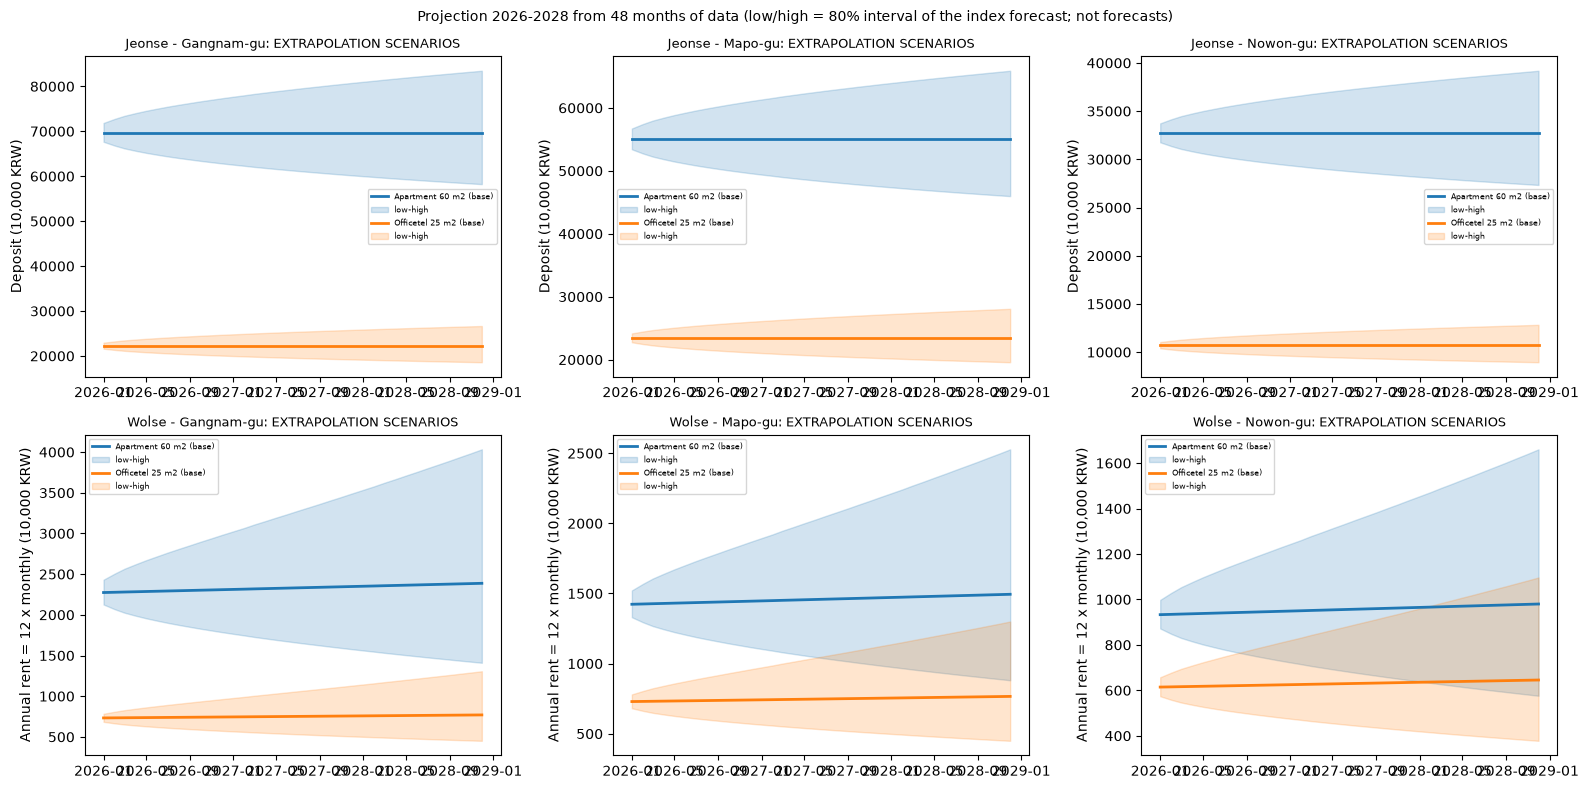

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for r, track in enumerate(config.TRACKS):
    for c, district in enumerate(['Gangnam-gu', 'Mapo-gu', 'Nowon-gu']):
        ax = axes[r, c]
        for btype, area, color in [('Apartment', 60.0, 'tab:blue'), ('Officetel', 25.0, 'tab:orange')]:
            table = projection[(track, f'{btype} {area:.0f} m2, {district}')]
            factor = 12 if track == 'wolse' else 1
            ax.plot(table.index, table['base'] * factor, color=color, lw=2, label=f'{btype} {area:.0f} m2 (base)')
            ax.fill_between(table.index, table['low'] * factor, table['high'] * factor, color=color, alpha=0.2, label='low-high')
        ax.set_title(f"{track.capitalize()} - {district}: EXTRAPOLATION SCENARIOS", fontsize=9)
        ax.set_ylabel('Deposit (10,000 KRW)' if track == 'jeonse' else 'Annual rent = 12 x monthly (10,000 KRW)')
        ax.legend(fontsize=6)
plt.suptitle('Projection 2026-2028 from 48 months of data (low/high = 80% interval of the index forecast; not forecasts)', fontsize=10)
plt.tight_layout(); plt.savefig(config.FIGURES_DIR / '09_projection_scenarios.png', dpi=130); plt.show()

**Interpretation.** The charts show the same scenarios as the table: flat base lines in Jeonse with bands that widen with the horizon, and slowly rising Wolse base lines with much wider bands (the 2028-12 80% intervals of the index forecasts are 86.83 to 124.45 for Jeonse and 54.45 to 154.82 for Wolse). The bands only reflect the uncertainty of the index level; they do not include the dispersion of individual contracts around the model, which is large (the chosen models have a WAPE of 17.4448% in Jeonse and 45.3293% in Wolse on 2025).

## Save the leaderboard

In [15]:
rows = []
for track in config.TRACKS:
    t = tables[track].set_index('model_id')
    for _, r in runs[runs['track'] == track].iterrows():
        entry = {'track': track, 'model_id': r['model_id'], 'family': r['family'], 'valid': r['valid'], 'extrapolation': r['extrapolation'],
                 'can_extrapolate': r['can_extrapolate'], 'complexity': r['complexity'], 'n': r['n'],
                 **{c: r[c] for c in ['wape_pct', 'mae', 'mdape_pct', 'median_bias_pct', 'aggregate_bias_pct', 'mape_dq_median_pct', 'mape_dq_max_pct', 'rmse_log', 'r2_log']}}
        if r['valid']:
            entry.update(diff_vs_leader=t.loc[r['model_id'], 'diff_vs_leader'], se_diff=t.loc[r['model_id'], 'se_diff'],
                         tie_with_leader=bool(t.loc[r['model_id'], 'tie_with_leader']))
        entry.update(is_unconstrained_leader=r['model_id'] == selection[track]['leader'] and bool(r['valid']),
                     is_chosen_model=r['model_id'] == selection[track]['winner'] and bool(r['valid']))
        rows.append(entry)
leaderboard = pd.DataFrame(rows)
leaderboard['rank_valid'] = leaderboard[leaderboard['valid']].groupby('track')['wape_pct'].rank(method='min')
leaderboard = leaderboard.sort_values(['track', 'valid', 'wape_pct'], ascending=[True, False, True])
leaderboard.to_csv(config.METRICS_DIR / 'leaderboard.csv', index=False)
print(f'reports/metrics/leaderboard.csv: {len(leaderboard)} rows; figures:', sorted(p.name for p in config.FIGURES_DIR.glob('09_*.png')))
print(leaderboard[leaderboard['is_chosen_model'] | leaderboard['is_unconstrained_leader']][['track', 'model_id', 'rank_valid', 'wape_pct', 'is_unconstrained_leader', 'is_chosen_model']].to_string(index=False))

reports/metrics/leaderboard.csv: 66 rows; figures: ['09_leaderboard.png', '09_projection_scenarios.png']
 track       model_id  rank_valid  wape_pct  is_unconstrained_leader  is_chosen_model
jeonse hgb_legal_dong      1.0000   15.8354                     True            False
jeonse     hybrid_hgb      6.0000   17.4448                    False             True
 wolse hgb_legal_dong      1.0000   44.3335                     True            False
 wolse  hgb_detrended      2.0000   45.3293                    False             True


**Interpretation.** `reports/metrics/leaderboard.csv` has 66 rows (both tracks, invalid runs included and flagged). The chosen models are `hybrid_hgb`, ranked 6th among the valid Jeonse runs, and `hgb_detrended`, ranked 2nd among the valid Wolse runs; `hgb_legal_dong` is the unconstrained leader of both tracks.

## Summary

## Conclusion

**Which model is best to estimate what a tenant will pay in future years?**

- **Jeonse: `hybrid_hgb`** (HGB structure model plus a forecasted quality-adjusted index), WAPE 17.4448% in 2025. It is the best of the models that can extrapolate a trend; the unconstrained leader `hgb_legal_dong` (15.8354%) uses no time information. The price of the requirement is 1.6094 points.
- **Wolse: `hgb_detrended`** (HGB on the detrended target with the trend added back), WAPE 45.3293%. It is also the best that can extrapolate; the price of the requirement is 0.9958 points with respect to `hgb_legal_dong` (44.3335%).
- **Supervised vs unsupervised.** Supervised boosting wins in both tracks. Unsupervised features do not improve boosting (changes between +0.0029 and +0.0661 points, except -0.1777 for `hgb_time_gmm` in Wolse), help ridge a little, and pure unsupervised predictors are the worst family.
- **Main limitation.** Only 48 months of data and a level shift in 2025 that no valid model anticipated: the chosen models underpredict in 2025 (aggregate bias -5.0263% in Jeonse and -22.4758% in Wolse), the bias of the Jeonse choice grows from Q1 to Q4, and the 2026-2028 scenarios are extrapolations whose bands (80% interval of the index) are wide, in particular in Wolse. They must be read as scenarios and not as forecasts.